In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive/colab')

['placement_dataset.csv',
 'age_insurance.csv',
 'titanic.zip',
 'train.csv',
 'placement_predict_50k Dataset (1).csv',
 'placement_predict_50k_adjusted (1).csv']

   Age  Insurance  InsurancePlan
0   56          0              0
1   69          1              2
2   46          1              2
3   32          0              0
4   60          1              2
(300, 3)

PART 1: BINARY LOGISTIC REGRESSION
---------------------------------------------
Accuracy: 0.7833333333333333
               precision    recall  f1-score   support

 No Insurance       0.77      0.68      0.72        25
Has Insurance       0.79      0.86      0.82        35

     accuracy                           0.78        60
    macro avg       0.78      0.77      0.77        60
 weighted avg       0.78      0.78      0.78        60

Confusion matrix:
 [[17  8]
 [ 5 30]]

Predictions: [0 1 1]
Age 22: Insurance = 0 (probability of Yes = 0.07)
Age 45: Insurance = 1 (probability of Yes = 0.68)
Age 63: Insurance = 1 (probability of Yes = 0.97)


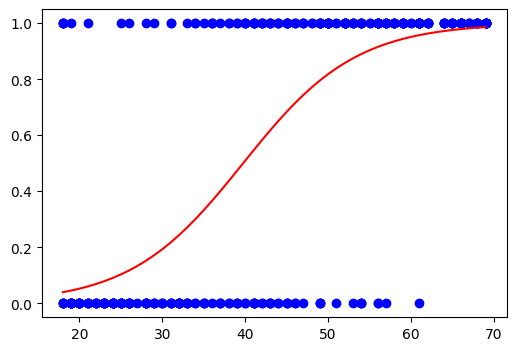

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------------------
# STEP 1: Load the data
# ---------------------------------------------------------

df = pd.read_csv("/content/drive/MyDrive/colab/age_insurance.csv")

print(df.head())
print(df.shape)

# ==========================================================
# PART 1: BINARY LOGISTIC REGRESSION
# Feature: Age -> Target: Insurance (0 = No, 1 = Yes)
# ==========================================================

print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)

X = df[["Age"]]              # Feature must be 2D -> double brackets
y = df["Insurance"]          # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

binary_model = LogisticRegression()
binary_model.fit(X_train, y_train)

y_pred = binary_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Insurance", "Has Insurance"]
    )
)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# ---------------------------------------------------------
# Predict for new people
# ---------------------------------------------------------

new_age = pd.DataFrame({"Age": [22, 45, 63]})

predictions = binary_model.predict(new_age)

print("\nPredictions:", predictions)

probabilities = binary_model.predict_proba(new_age)[:, 1]
# probability of "Yes"

for age_val, pred, prob in zip(
    new_age["Age"], predictions, probabilities
):
    print(
        f"Age {age_val}: Insurance = {pred} "
        f"(probability of Yes = {prob:.2f})"
    )

# ---------------------------------------------------------
# Simple plot: Age vs Insurance with model's S-curve
# ---------------------------------------------------------

plt.figure(figsize=(6, 4))

plt.scatter(
    df["Age"],
    df["Insurance"],
    color="blue",
    label="Actual data"
)

age_range = pd.DataFrame({
    "Age": range(18, 70)
})

plt.plot(
    age_range["Age"],
    binary_model.predict_proba(age_range)[:, 1],
    color="red",
    label="Predicted probability"
)